# Bayesian inference model: partial pooling, hierarchical prior

### How the hierarchical prior is built

The broad prior becomes the hyperprior: the starting belief about the typical
farm-season. Targets in the earliest season year have no history, so they fall back to the
broad prior (i.e. the unpooled model).

This notebook can only fit the posterior per season/year to avoid leaking "future" data into earlier farm-seasons.

Hierarchical prior is built in 2 stages:

**Stage 1: learn from history (one fit per target season year).**
A single model is fit to all farm-seasons from years strictly before the target season, across every farm and state. It estimates:

- the typical value of each parameter across all history (`mu_*`)
- each state's offset from typical, for states with ≥ 3 farms in the history (GreenWave's requested 3 to be the min threshold to use regional information)
- each farm's offset from typical across all farms, from that farm's past seasons
- each past season's deviation from its farm's usual level
- the spreads of those offsets: how much states differ (`sd_state_*`), how much farms
  differ (`sd_farm_*`), and how much a farm varies year to year (`sd_season_*`)

The target farm's own past seasons and its state's past seasons are part of this fit, but so is
everyone else's, because the spreads can only be learned by comparing many farms and seasons. The
spreads decide how far each farm's offset is pulled toward typical. In other words, a farm with several consistent seasons keeps most of its own offset, and a farm with little or noisy history is pulled toward the typical value. One fit covers every target farm in that season year. It's cached to disk, and it's refit per year because each year has a different history.

This gives us a "posterior" distribution over the hyperparameters listed talked about above and listed below:
- `mu_*` - where the population centres per model parameter
- `sd_*`- for how much states, farms, and seasons differ per model parameter
- `z_state_*`- each specific state's offset per model parameter
- `z_farm_*`- each specific farm's offset per model parameter


**Stage 2: compose a prior for the target's next season.**
For every Stage 1 posterior draw:

    new season = typical + state offset + farm offset + a fresh season deviation

- A farm with no history draws its farm offset fresh from `Normal(0, sd_farm)`.
- A state below the farm threshold adds no offset.
- The season deviation is drawn from `Normal(0, sd_season)` and not taken from any past season because the target season's own deviation from past seasons is unknown until observations arrive.

The draws are summarized as a multivariate normal with full covariance, so parameter correlations
(e.g. plateau vs harvest calibration) survive, and PyMC uses it as an ordinary prior. The target
season's data is never involved in Stages 1 or 2 along with any of its future season data.

Now, we can fit the final posterior for the target farm-season.

From that prior, the target farm-season is fit exactly like the unpooled model: refit after each
sample or harvest, using only readings logged before the forecast day. This is where the target
season's own deviation gets learned.

Same settings as the unpooled, broad prior but can change configurations based on quality of posterior fit (look at diagnostics).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from greenwave import evaluate as ev
from greenwave import model as mdl
from greenwave import plots as pl
from greenwave import preprocess as pre

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({"figure.dpi": 110})

# data source, fill out
XLSX = "../20260724_kcf_export_anonymized.xlsx"
CACHE_DIR = "../output/"
# SEASON is a filter, still fits posterior for all seasons/years
SEASON = "Season 25/26"      # set to None for all seasons

# mcmc sampler configuration for all stages
SAMPLER = dict(draws=1000, tune=1000, chains=4, target_accept=0.9, seed=0)

# to name the cached files of the posteriors
RUN = "v1"

# same as the unpooled model
events, data_meta = pre.load_dataset(XLSX)
line_events = pre.load_line_events(XLSX, events)
fsids = ev.scorable_farm_seasons(events)      # ALL seasons
# sort the farm seasons on whether they have samples and harvests + some extra info
candidates = ev.describe_farm_seasons(events, season=SEASON)

REPORT_FSID = candidates.index[0]
print(f"\nillustrating with {REPORT_FSID} "
      f"({candidates.loc[REPORT_FSID, 'n_samples']} samples, "
      f"{candidates.loc[REPORT_FSID, 'n_harvests']} harvests)")
print(" Can change the farm-season id later in the notebook to check others\n")

print(f"{len(fsids)} scorable farm-seasons across {events['Season'].nunique()} seasons")
print(events[events.farm_season_id.isin(fsids)].groupby("Season")["farm_season_id"]
      .nunique().to_string())



1,561 events | 155 farm-seasons | 74 farms | 4 seasons
source 20260724_kcf_export_anonymized.xlsx (sha1 55b5757610b6) | data fingerprint 1964ba10

illustrating with F2_2526 (19 samples, 9 harvests)
 Can change the farm-season id later in the notebook to check others

107 scorable farm-seasons across 4 seasons
Season
Season 22/23    20
Season 23/24    39
Season 24/25    31
Season 25/26    17


## Stage 1 — learn the population from history

One joint fit per target season year, over the farm-seasons strictly earlier than it. Cached to disk.

Check the stage 1 fits diagnostics. For instance, Season 25/26 has no divergences but low ess and high rhat. 

In [2]:
from greenwave import hierarchy as hi

BROAD_PRIOR = dict(mdl.BROAD_PRIOR) # hyper prior
# seasons with previous seasons... no Season 22/23
HISTORY_SEASONS = ["Season 23/24", "Season 24/25", "Season 25/26"]

# Stage 1 
stage1 = {s: hi.run_stage1(events, s, CACHE_DIR, broad_prior=BROAD_PRIOR)
          for s in HISTORY_SEASONS}
# check health
hi.stage1_health(stage1)


,history_farm_seasons,farms,states,max_rhat,min_ess_bulk,divergences,params_flagged,worst
season,,,,,,,,
Season 23/24,38,38,"AK, CT, ME, NY, RI",1.013082,606.936751,0,2,"sd_season_logc, sd_season_logsh"
Season 24/25,86,60,"AK, BC, CT, ME, NY, RI",1.005074,628.490702,0,0,
Season 25/26,123,69,"AK, BC, CT, ME, NY, RI, WA",1.083169,33.885732,0,4,"sd_season_logk, sd_farm_logc, sd_season_logc"


## Stage 2 — compose it into a prior for the target

Compose stage 1 into a prior for the target's farm and state where the prior =
global mean + state offset + farm offset + a fresh season deviation.

The state offset is how this farm's state differs for model parameters A, k, and t0.

The farm offset is how this farm differs for model parameter c only using only the target farm's earlier seasons.

Fresh season deviation is unknown, so its drawn from the learned season spread.

sigma_h only gets the global mean and the season draw. sigma keeps the broad prior as the season's own samples pin down its distribution. 

This hierarchical prior differs per farm-season. 

Can compare the hierarhical prior to the broad prior.


In [3]:
# Stage 2 
prior_for = hi.hierarchical_prior_for(events, stage1, broad_prior=BROAD_PRIOR)
MODEL = "hierarchical"

CACHE_NAME = mdl.cache_name(RUN, MODEL, SAMPLER, data_meta, prior=None)
print(f"cache file: {CACHE_NAME}.pkl")

# what the learned prior actually looks like next to the broad one it came from
mdl.compare_priors({"broad (hyperprior)": mdl.unpooled_prior_for(BROAD_PRIOR)(),
                   f"hierarchical {REPORT_FSID}": prior_for(REPORT_FSID)})


cache file: v1_hierarchical_d1000_t1000_c4_ta90_s0_x1964ba10.pkl


broad (hyperprior)                        hierarchical F2_2526                        
                    median       lo95        hi95               median        lo95        hi95
param                                                                                         
A                 4.018696   0.821604   18.961657             6.215497    1.263875   29.928660
k                 0.049900   0.011673    0.217823             0.048863    0.028451    0.083969
t0              149.728587  60.516619  238.654873           226.123079  184.216458  268.100034
c                 0.648184   0.330810    1.293977             0.578338    0.270413    1.265937
sigma             0.498167   0.103525    2.428272             0.498907    0.104400    2.388405
sigma_h           0.498907   0.104400    2.388405             0.649502    0.107653    3.890736

## Posteriors
Creates a cache based on the mcmc sampler settings and binds the events and prior to the cache to represent the Bayesian model.

There will be nothing in the cache for a run with new settings.

In [4]:
cache = mdl.PosteriorCache(sampler=SAMPLER)
cache.load(CACHE_NAME, CACHE_DIR)

model = mdl.SeasonModel(events, prior_for, cache, sampler=SAMPLER,
                       line_events=line_events)
print(f"{len(cache)} posteriors available")


LOADED 345 posteriors from /Users/gracegibson/work/green_wave/greenwave/output/v1_hierarchical_d1000_t1000_c4_ta90_s0_x1964ba10.pkl (70 distinct prior fingerprints: 082ff536, 0e1dfb3d, 1cb48b2d, 1d50b84d, 28e2119b, 307886cf, 328a02de, 35d18786, 37d7e1ff, 38df8357, 3a44f73b, 43600567, 46682357, 49afa37e, 49d49986, 4e19ad09, 4e6c8b3d, 4f7246e9, 5066bb25, 53363ea9, 5542b73f, 56c79e2c, 5965c72c, 5bc0ed55, 5e6e34f1, 60982e43, 6298996a, 6313aa79, 66a8d4cd, 6a5b1117, 6e1a8fc3, 7218f1f5, 734a3b70, 748efa86, 75669fbc, 777a0187, 790518c6, 7bf204ca, 7f95ecc4, 8cdc53e5, 8e42805e, 91c505a6, 93c0270e, a112e9e9, a310f128, a754c3e9, a8f9a7ae, aa0e78a1, ad545b10, afc487af, b00d3bd3, b229e18b, b452e3e0, b475922e, b9ae7978, b9c3a12e, bc2e2558, bff0a42e, c42f85ef, c6613860, cab8b070, cc0dfa70, cc807c28, d1c6a01e, d4533821, d562a429, e0906c4e, ed6f3c21, f66d5e54, fe46dce6)
345 posteriors available


## Predict

Predict the harvest density (lbs/ft) from a posterior conditioned on a particular subset of data for a specific target day (could be day of harvest or in the future).

* **conditioning** — what the model was allowed to see (`as_of=` a date or a
  day of season, or `n_obs=` a count). Model can only see observations before that date or up to that count.
  
  For example, if I give a `as_of` date of May 12th. The posterior would see all the observations logged on May 11th and before. But not observations logged on May 12th. As you could not use that posterior to predict May 12th logs (data leakage). For n_obs=19, the posterior would see the first 19 observations of the farm-season ordered by date.
* **target day** — the day you are asking about, which does not need to be a day anything was logged or observed, and may be in the future.

Both cells below take their dates, line length and target date from
`REPORT_FSID`'s own logged harvests. Can change to answer your own questions.


In [5]:
# Take one harvest, and forecast from posteriors constructed from incrementally earlier time frames
obs = model.observations(REPORT_FSID)
target = obs[obs.event == "harvest"].iloc[0]          # its first real harvest
print(f"target: harvest on {target.date} (day {target.day:.0f}), "
      f"{target.line_ft:,.0f} ft cut, actual {target.lbs_ft:.2f} lbs/ft")

views = {}
for weeks in (4, 2, 0):
    views["day before" if weeks == 0 else f"{weeks} weeks before"] = model.predict(
        model.posterior(REPORT_FSID, as_of=target.day - weeks * 7),
        day=target.day, line_ft=target.line_ft)

rows = ["n_obs_seen", "last_obs_day", "gap_days", "harvest_lbs_ft",
        "yield_lo95", "yield_hi95", "reading_lo95", "reading_hi95",
        "lbs", "lbs_lo95", "lbs_hi95"]
look_back = pd.DataFrame(views).loc[rows]
# add the true harvested lbs/ft
look_back["ACTUAL"] = [np.nan] * 3 + [target.lbs_ft] + [np.nan] * 4 + \
                      [target.lbs_ft * target.line_ft] + [np.nan] * 2
look_back.round(2)


target: harvest on 2026-05-13 (day 224), 400 ft cut, actual 2.80 lbs/ft


,4 weeks before,2 weeks before,day before,ACTUAL
n_obs_seen,9,13,19,NaN
last_obs_day,164.0,199.0,219.0,NaN
gap_days,60.0,25.0,5.0,NaN
harvest_lbs_ft,3.061131,2.996866,2.528333,2.8
yield_lo95,0.97961,1.254819,1.126411,NaN
yield_hi95,10.288164,7.061501,5.502306,NaN
reading_lo95,0.0,0.0,0.0,NaN
reading_hi95,11.324484,8.388829,7.157745,NaN
lbs,1224.452431,1198.746421,1011.333174,1120.0
lbs_lo95,391.843835,501.927599,450.564433,NaN


In [6]:
# take one posterior and ask about the predicted harvest lbs/ft at future dates
post = model.posterior(REPORT_FSID, as_of=target.day)   # what was known the day before

ahead = pd.DataFrame({
    (f"day {target.day + d:.0f}" + (" (the harvest)" if d == 0 else f" (+{d}d)")):
        model.predict(post, target.day + d, line_ft=target.line_ft)
    for d in (0, 14, 28)
}).loc[["gap_days", "harvest_lbs_ft", "yield_lo95", "yield_hi95",
        "reading_lo95", "reading_hi95"]]
print(f"as of day {post['_last_day']:.0f} ({post['_n_seen']} observations seen); "
      f"the interval widens as the gap grows, because the forecast is "
      f"extrapolating along a curve the data has not checked out there")
ahead.round(2)


as of day 219 (19 observations seen); the interval widens as the gap grows, because the forecast is extrapolating along a curve the data has not checked out there


,day 224 (the harvest),day 238 (+14d),day 252 (+28d)
gap_days,5.0,19.0,33.0
harvest_lbs_ft,2.528333,2.903381,3.200361
yield_lo95,1.126411,1.276066,1.368524
yield_hi95,5.502306,6.565435,7.550978
reading_lo95,0.0,0.0,0.0
reading_hi95,7.157745,7.882367,8.707528


## Replay the season

Per observation or event logged, let's look at the posterior prediction and range before and after the obs was logged. 

There's a yield range and a reading range.
The yield range looks at the x number of posterior samples and computes the 95% interval of the distribution using only the curve parameters (A, k, t0, and c). The reading range incorporates sigma_h or the noise around the curves. So, this range is wider.



In [7]:
# The season replayed: one row per event, the forecast BEFORE it was logged
# and again AFTER. Always numeric, always lbs/ft.
report = model.report(REPORT_FSID)
pl.view(report, "all").round(2)


Farm_2 Season 25/26 (AK) — 9 harvests, 19 samples  [prior: hierarchy (Farm_2, AK)]
  harvest actuals inside the 95% yield range: 5/9   reading range: 9/9
  cache for season_report F2_2526: 61 hits, 0 fitted  (345 stored)


,farm_season_id,date,day,event,n_samples_seen,n_harvests_seen,gap_days,actual_lbs_ft,actual_lbs,line_harvested_ft,line_in_water_ft,pred_sample_lbs_ft,sample_yield_lo95,sample_yield_hi95,pred_harvest_lbs_ft,harvest_yield_lo95,harvest_yield_hi95,harvest_reading_lo95,harvest_reading_hi95,pred_sample_lbs_ft_after,sample_yield_lo95_after,sample_yield_hi95_after,pred_harvest_lbs_ft_after,harvest_yield_lo95_after,harvest_yield_hi95_after,harvest_reading_lo95_after,harvest_reading_hi95_after,naive_lbs_ft,in95_yield,in95_reading
0,F2_2526,2025-11-12,42.0,outplant,0,0,NaN,0.00,NaN,NaN,4800.0,0.00,0.00,0.06,0.00,0.00,0.04,0.00,4.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,F2_2526,2025-11-13,43.0,outplant,0,0,NaN,0.00,NaN,NaN,10000.0,0.00,0.00,0.07,0.00,0.00,0.04,0.00,3.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,F2_2526,2025-11-19,49.0,outplant,0,0,NaN,0.00,NaN,NaN,20000.0,0.00,0.00,0.08,0.00,0.00,0.05,0.00,3.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,F2_2526,2026-01-18,109.0,outplant,0,0,NaN,0.00,NaN,NaN,22000.0,0.02,0.00,0.53,0.01,0.00,0.33,0.00,3.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,F2_2526,2026-01-20,111.0,outplant,0,0,NaN,0.00,NaN,NaN,23200.0,0.02,0.00,0.58,0.01,0.00,0.36,0.00,3.57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,F2_2526,2026-03-04,154.0,sample,0,0,NaN,0.01,NaN,NaN,23200.0,0.19,0.00,2.48,0.10,0.00,1.59,0.00,4.20,0.09,0.00,0.74,0.05,0.00,0.53,0.00,3.85,0.00,None,None
6,F2_2526,2026-03-04,154.0,sample,1,0,0.0,1.10,NaN,NaN,23200.0,0.09,0.00,0.74,0.05,0.00,0.53,0.00,4.04,0.22,0.00,1.13,0.12,0.00,0.79,0.00,3.97,0.00,None,None
7,F2_2526,2026-03-04,154.0,sample,2,0,0.0,0.61,NaN,NaN,23200.0,0.22,0.00,1.13,0.12,0.00,0.79,0.00,3.91,0.30,0.01,1.00,0.17,0.00,0.73,0.00,4.16,0.00,None,None
8,F2_2526,2026-03-04,154.0,sample,3,0,0.0,0.97,NaN,NaN,23200.0,0.30,0.01,1.00,0.17,0.00,0.73,0.00,3.87,0.49,0.01,1.08,0.26,0.01,0.86,0.00,3.76,0.00,None,None
9,F2_2526,2026-03-14,164.0,sample,4,0,10.0,0.50,NaN,NaN,23200.0,0.72,0.02,1.59,0.39,0.01,1.28,0.00,4.29,0.62,0.04,1.30,0.33,0.02,1.11,0.00,3.70,0.67,None,None


### Season replayed in lbs

GreenWave has typically represented the biomass in the water as lbs. This function converts the harvest density into lbs given the current kelp line length outplanted.

There are 2 views:
- `add_harvest_pounds`: add the actual harvested lbs versus predicted harvested lbs and range using the harvested line length logged. This is for evaluating the prediction versus the actual logged harvest in lbs, not only lbs/ft in the last section.
- `add_biomass_in_water`: add the predicted biomass in water and its range. Multiplies the predicted harvest lbs/ft and range by the line length in the water. This line length changes based on outplanting, line loss, and harvesting events. This is what a farmer could see as they log events; a running total of lbs, not lbs/ft.

In [8]:
# Two different pounds questions, two functions, two line lengths.
#   in water  -> what is standing now (the app's number), every row
#   harvest   -> was this harvest's prediction right, harvest rows only
pl.view(pl.add_harvest_pounds(report), ["keys", "truth", "pounds"]).round(1)


,farm_season_id,date,day,event,actual_lbs_ft,actual_lbs,line_harvested_ft,line_in_water_ft,pred_lbs_med,pred_lbs_lo95,pred_lbs_hi95,pred_lbs_reading_lo95,pred_lbs_reading_hi95,err_lbs
0,F2_2526,2025-11-12,42.0,outplant,0.0,NaN,NaN,4800.0,NaN,NaN,NaN,NaN,NaN,NaN
1,F2_2526,2025-11-13,43.0,outplant,0.0,NaN,NaN,10000.0,NaN,NaN,NaN,NaN,NaN,NaN
2,F2_2526,2025-11-19,49.0,outplant,0.0,NaN,NaN,20000.0,NaN,NaN,NaN,NaN,NaN,NaN
3,F2_2526,2026-01-18,109.0,outplant,0.0,NaN,NaN,22000.0,NaN,NaN,NaN,NaN,NaN,NaN
4,F2_2526,2026-01-20,111.0,outplant,0.0,NaN,NaN,23200.0,NaN,NaN,NaN,NaN,NaN,NaN
5,F2_2526,2026-03-04,154.0,sample,0.0,NaN,NaN,23200.0,NaN,NaN,NaN,NaN,NaN,NaN
6,F2_2526,2026-03-04,154.0,sample,1.1,NaN,NaN,23200.0,NaN,NaN,NaN,NaN,NaN,NaN
7,F2_2526,2026-03-04,154.0,sample,0.6,NaN,NaN,23200.0,NaN,NaN,NaN,NaN,NaN,NaN
8,F2_2526,2026-03-04,154.0,sample,1.0,NaN,NaN,23200.0,NaN,NaN,NaN,NaN,NaN,NaN
9,F2_2526,2026-03-14,164.0,sample,0.5,NaN,NaN,23200.0,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
pl.view(pl.add_biomass_in_water(report, line_events),
        ["keys", "truth", "pounds"]).round(0)


,farm_season_id,date,day,event,actual_lbs_ft,actual_lbs,line_harvested_ft,line_in_water_ft,lbs_in_water_sample_med,lbs_in_water_sample_lo95,lbs_in_water_sample_hi95,lbs_in_water_med,lbs_in_water_lo95,lbs_in_water_hi95
0,F2_2526,2025-11-12,42.0,outplant,0.0,NaN,NaN,4800.0,4.0,0.0,307.0,2.0,0.0,178.0
1,F2_2526,2025-11-13,43.0,outplant,0.0,NaN,NaN,10000.0,8.0,0.0,656.0,5.0,0.0,382.0
2,F2_2526,2025-11-19,49.0,outplant,0.0,NaN,NaN,20000.0,22.0,0.0,1555.0,13.0,0.0,903.0
3,F2_2526,2026-01-18,109.0,outplant,0.0,NaN,NaN,22000.0,463.0,3.0,11763.0,260.0,2.0,7353.0
4,F2_2526,2026-01-20,111.0,outplant,0.0,NaN,NaN,23200.0,540.0,4.0,13354.0,304.0,2.0,8298.0
5,F2_2526,2026-03-04,154.0,sample,0.0,NaN,NaN,23200.0,4297.0,108.0,57513.0,2432.0,58.0,36979.0
6,F2_2526,2026-03-04,154.0,sample,1.0,NaN,NaN,23200.0,2011.0,67.0,17245.0,1163.0,32.0,12250.0
7,F2_2526,2026-03-04,154.0,sample,1.0,NaN,NaN,23200.0,5012.0,112.0,26144.0,2789.0,63.0,18213.0
8,F2_2526,2026-03-04,154.0,sample,1.0,NaN,NaN,23200.0,6912.0,166.0,23262.0,3875.0,93.0,16927.0
9,F2_2526,2026-03-14,164.0,sample,0.0,NaN,NaN,23200.0,16740.0,578.0,37002.0,8936.0,319.0,29801.0


## Evaluation

`harvest_predictions` fits the posterior for all harvest events across all farm-seasons given based on a global prior. Can define what estimator you want to use for the harvest prediction from the posterior distribution.
Currently, use median. Based on the unpooled model.

Evaluate those results per season and farm season and compare to the "naive" approach: GreenWave's current method of using the most recent observation (avg if multiple on one day). 
mae = mean absolute error
medae = median absolute error

In [10]:
preds_all = ev.harvest_predictions(events, fsids, prior_for, cache,
                                   estimator="median", sampler=SAMPLER,
                                   method=MODEL, verbose=True)

# filter to the season of interest
preds = preds_all if SEASON is None else preds_all[preds_all.season == SEASON]
print(f"\nscoring {len(preds)} of {len(preds_all)} harvest events"
      + (f" ({SEASON})" if SEASON else " (all seasons)"))
ev.evaluate(preds).T.round(2)


325 harvest events over 107 farm-seasons [estimator=median]
  cache for harvest_predictions: 325 hits, 0 fitted  (345 stored)

scoring 83 of 325 harvest events (Season 25/26)


method,hierarchical
harvests,83.00
farm_seasons,17.00
yield_mae,1.08
yield_medae,0.84
naive_yield_mae,1.21
naive_yield_medae,0.88
total_mae_lbs,6052.68
total_medae_lbs,3099.54
naive_total_mae_lbs,8127.66
naive_total_medae_lbs,2445.38


In [11]:
# evaluate per farm season using only the point estimate (i.e. median)
# each harvest forecast comes from its own posterior
# can't sum the ranges easily so give a count of n_harvesets within each 95% range
ev.by_farm_season(preds).sort_values("actual_lbs", ascending=False).round(1)


,method,farm_season_id,farm,season,n_harvests,actual_lbs,pred_lbs,n_in95_yield,n_in95_reading,naive_lbs,n_harvests_naive,n_harvests_in_season,err_lbs,abs_err_lbs,pct_err,naive_err_lbs,naive_abs_err_lbs,naive_pct_err,winner
1,hierarchical,F13_2526,Farm_13,Season 25/26,5,260564.6,239513.6,5,5,221324.9,5,5,-21051.0,21051.0,-8.1,-39239.7,39239.7,-15.1,model
4,hierarchical,F2_2526,Farm_2,Season 25/26,9,86200.0,75160.8,5,9,84244.0,9,9,-11039.2,11039.2,-12.8,-1956.0,1956.0,-2.3,naive
5,hierarchical,F37_2526,Farm_37,Season 25/26,8,69610.0,78141.6,5,8,87383.1,8,8,8531.6,8531.6,12.3,17773.1,17773.1,25.5,model
10,hierarchical,F55_2526,Farm_55,Season 25/26,2,62927.0,66026.5,2,2,95700.0,2,2,3099.5,3099.5,4.9,32773.0,32773.0,52.1,model
15,hierarchical,F80_2526,Farm_80,Season 25/26,12,53646.0,68773.9,6,11,56629.0,12,12,15127.9,15127.9,28.2,2983.0,2983.0,5.6,naive
2,hierarchical,F1_2526,Farm_1,Season 25/26,6,42359.0,42905.1,4,5,39913.6,6,6,546.1,546.1,1.3,-2445.4,2445.4,-5.8,model
8,hierarchical,F48_2526,Farm_48,Season 25/26,10,42203.5,64424.6,7,10,64312.2,10,10,22221.1,22221.1,52.7,22108.7,22108.7,52.4,naive
7,hierarchical,F43_2526,Farm_43,Season 25/26,3,17471.0,13270.5,2,2,12871.2,3,3,-4200.5,4200.5,-24.0,-4599.8,4599.8,-26.3,model
9,hierarchical,F4_2526,Farm_4,Season 25/26,4,16337.0,14294.8,4,4,17068.5,4,4,-2042.2,2042.2,-12.5,731.5,731.5,4.5,naive
16,hierarchical,F83_2526,Farm_83,Season 25/26,3,15525.5,9568.2,2,2,14305.5,3,3,-5957.3,5957.3,-38.4,-1220.0,1220.0,-7.9,naive


### Every season, side by side

Summary of prediction results per season versus GreenWave's naive approach.


In [12]:
by_season = pd.concat(
    [ev.evaluate(g).assign(season=s) for s, g in preds_all.groupby("season")]
).set_index("season")
by_season[["harvests", "farm_seasons", "yield_mae", "naive_yield_mae",
           "total_mae_lbs", "naive_total_mae_lbs",
           "farm_seasons_won", "farm_seasons_lost"]].round(2)


,harvests,farm_seasons,yield_mae,naive_yield_mae,total_mae_lbs,naive_total_mae_lbs,farm_seasons_won,farm_seasons_lost
season,,,,,,,,
Season 22/23,20,20,1.08,1.58,7727.46,9150.77,12,8
Season 23/24,136,39,1.66,1.64,5333.95,4196.56,19,20
Season 24/25,86,31,1.31,1.41,5155.62,11836.07,14,17
Season 25/26,83,17,1.08,1.21,6052.68,8127.66,9,8


## Coverage of actual harvested lbs/ft by 95% range
There are 2 95% ranges that come with each posterior's prediction of a harvest:
- **95% yield interval**: the 95% range (2.5-97.5 percentiles of the posterior distribution) of the draws per chain * chains draws of the posterior for model parameters: A, k, t0, c. This is the 95% range of the model's prediction.
- **95% reading interval**: includes the yield interval + posterior draws of sigma_h. This is the 95% range of the actual lbs/ft harvested from the line as sigma_h is the scatter, or uncertainty, of the harvest amounts from the curve.

`harvest_coverage` gives a True/False if the actual harvest lbs/ft falls within either of the 2 ranges per harvest event for all of the farm-seasons within `SEASON`. 
Can change to `all_preds` if want coverage results across all seasons.

The ranges are clipped at 0 because a negative kelp density (lbs/ft) is impossible.

In [13]:
cov, cov_summary = ev.harvest_coverage(
    events, sorted(preds.farm_season_id.unique()), prior_for, cache, label=MODEL)
cov[["farm", "day", "actual_lbs_ft", "pred_med", "yield_lo95", "yield_hi95",
     "reading_lo95", "reading_hi95", "in95_yield", "in95_reading"]].head(10).round(2)


[hierarchical] 83 harvests over 17 farm-seasons
  cache for harvest_coverage: 83 hits, 0 fitted  (345 stored)
  inside 95% reading interval: 92.8%  (median width 2.0x the prediction)
  inside 95% yield interval:   72.3%  (median width 0.9x)
  misses: 6 above, 0 below


,farm,day,actual_lbs_ft,pred_med,yield_lo95,yield_hi95,reading_lo95,reading_hi95,in95_yield,in95_reading
0,Farm_12,228.0,2.49,2.11,0.95,4.76,0.00,6.79,True,True
1,Farm_12,228.0,2.50,2.38,1.23,3.58,0.00,5.22,True,True
2,Farm_13,214.0,3.85,1.57,0.16,11.63,0.00,12.40,True,True
3,Farm_13,216.0,4.17,3.71,0.56,5.52,0.00,7.16,True,True
4,Farm_13,218.0,4.69,4.18,2.46,5.02,1.74,5.99,True,True
5,Farm_13,220.0,4.05,4.58,3.57,5.37,2.60,6.04,True,True
6,Farm_13,222.0,4.26,4.42,3.79,5.19,2.90,5.86,True,True
7,Farm_1,208.0,0.78,1.99,0.80,4.76,0.00,6.66,False,True
8,Farm_1,235.0,3.53,2.40,1.00,7.29,0.00,8.71,True,True
9,Farm_1,235.0,3.73,3.29,1.62,5.11,0.11,6.57,True,True


## MCMC Sampler diagnostics
Diagnostics for the MCMC Sampler that gives us the posterior distribution include:
- r_hat: compares the between chain variance to the within chain variance. If the chains have mixed well and thoroughly explored the posterior's probability space, then the chains should mostly agree and r_hat should be less than or equal to 1.01 (given no negative correlations).
- ess: effective sample size, estimates the number of independent, uncorrelated samples or draws of the posterior. Aim for 400 total as a rule of thumb.
- divergences: means a divergence from mapping the target distribution (i.e. posterior). Could happen if the MCMC sampler encounters a steep ridge in the posterior space and the step size its using can't handle that jump to determine the shape there. Want 0 of those!

In [14]:
# filter to this sampler setting -- a cache can hold several, and pooling
# them makes healthy fits look bad
diag = mdl.posterior_diagnostics(cache, fsids=fsids)
diag = diag[diag.method == "mcmc"]
mdl.diagnostics_summary(diag)

# Monte Carlo error on a quoted number -- how much it would move on another
# seed, against the posterior sd it competes with
mdl.forecast_mc_error(post, 224)


  posteriors fitted      334
  prior-only rows        0
  % r_hat <= 1.01        97.9
  % r_hat <= 1.05        100.0
  worst r_hat            1.0
  median ess             1,328.0
  min ess                329.9
  n with ess < 400       2
  n with divergences     0
  worst offenders (of 7 flagged):
farm_season_id  n_seen    r_hat        ess  divergences       flag
      F13_2526       3 1.017252 329.943019          0.0 r_hat>1.01
      F48_2526       7 1.016312 399.823635          0.0 r_hat>1.01
      F48_2526       6 1.011451 505.197706          0.0 r_hat>1.01
       F3_2324       9 1.011278 535.748601          0.0 r_hat>1.01
      F19_2425       6 1.017295 580.433571          0.0 r_hat>1.01


{'posterior_sd': 1.1450998188942334,
 'mcse_mean': 0.021682844442898915,
 'mcse_q0.025': 0.0197197959180635,
 'mcse_q0.5': 0.021430968075042856,
 'mcse_q0.975': 0.09991797445219364,
 'ess': 1450.8557209030926}

### One posterior across the season

Did the forecast hold up on data it never saw?
Takes a posterior `as_of` a particular date or that has seen `n_obs` of a farm-season and plots the median curve from that posterior distribution and its 95% ranges against that farm-season's observations. 

Observation type is based on shape
- squares = outplant
- samples = circles
- harvests = stars

The observation is filled in if the observation has been seen by the posterior.

"95% - the farm's average that day" is the 95% range of the posterior samples for the curve parameters: A, k, t0, c
"95% - any single cut" is the 95% range of the posterior samples for the curve parameters + sigma_h or the scatter around those curves


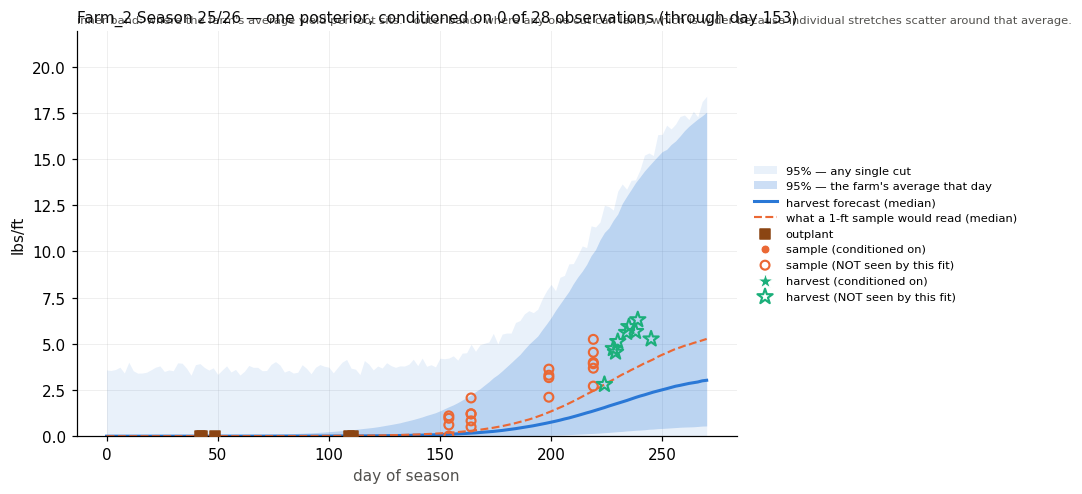

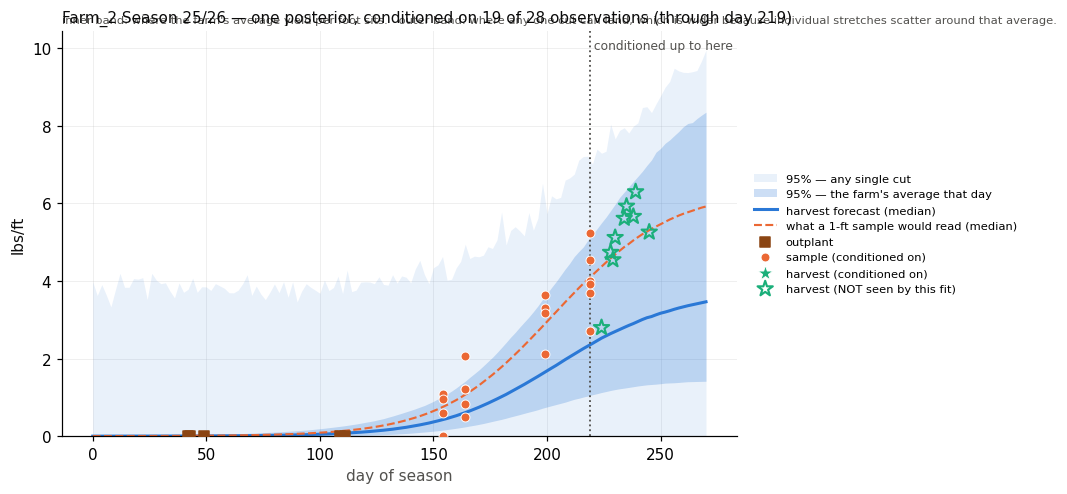

In [15]:
for as_of, n_obs in [(None, 0), (target.day, None)]:
    pl.plot_season_curves(model, REPORT_FSID, as_of=as_of, n_obs=n_obs)
    plt.show()


## Save
save the posteriors to the "cache"

In [16]:
cache.save(CACHE_NAME, CACHE_DIR)


SAVED 345 posteriors -> /Users/gracegibson/work/green_wave/greenwave/output/v1_hierarchical_d1000_t1000_c4_ta90_s0_x1964ba10.pkl (33.2 MB)


PosixPath('../output/v1_hierarchical_d1000_t1000_c4_ta90_s0_x1964ba10.pkl')